# Feature Extraction

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Scale Invarient Feature Transform [SIFT]

In [2]:
img = cv2.imread("flower.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img

array([[ 15,  15,  15, ...,  90, 100, 106],
       [ 15,  15,  15, ...,  90, 100, 106],
       [ 14,  15,  15, ...,  90, 100, 106],
       ...,
       [ 18,  19,  19, ...,   0,   0,   0],
       [ 18,  19,  19, ...,   0,   0,   0],
       [ 18,  20,  20, ...,   0,   0,   0]], shape=(635, 950), dtype=uint8)

Number of Keypoints Detected: 761
Descriptor Shape: (761, 128)

First Descriptor (128-dimensional):
[ 42.  39.   1.   0.   0.   0.   0.   1. 138. 131.   7.  15.  11.   1.
   0.   4.  35.  38.  12.  95. 115.   3.   0.   1.  80.  71.  10.  16.
  17.   2.   0.   0.  77.  10.   0.   0.   0.   0.   0.   7. 138.  34.
   3.   7.  22.  10.   4.  56.  41.  31.  10.  56. 138.  36.   4.  15.
  25. 129.  52.  30.  22.   0.   0.   0.  64.  24.   0.   0.   0.   0.
   0.   2. 138. 122.  22.  39.  15.   1.   0.   8.  18.  28.  24. 138.
 138.   4.   3.   3.   0.  37.  47.  31.  19.   5.   3.   1.  21.   3.
   0.   0.   0.   0.   2.  11.  91.  46.  12.  25.  10.   0.   2.  11.
   8.  13.  10.  64.  58.   3.   5.   7.   3.   3.   2.   3.  11.  30.
  12.  10.]


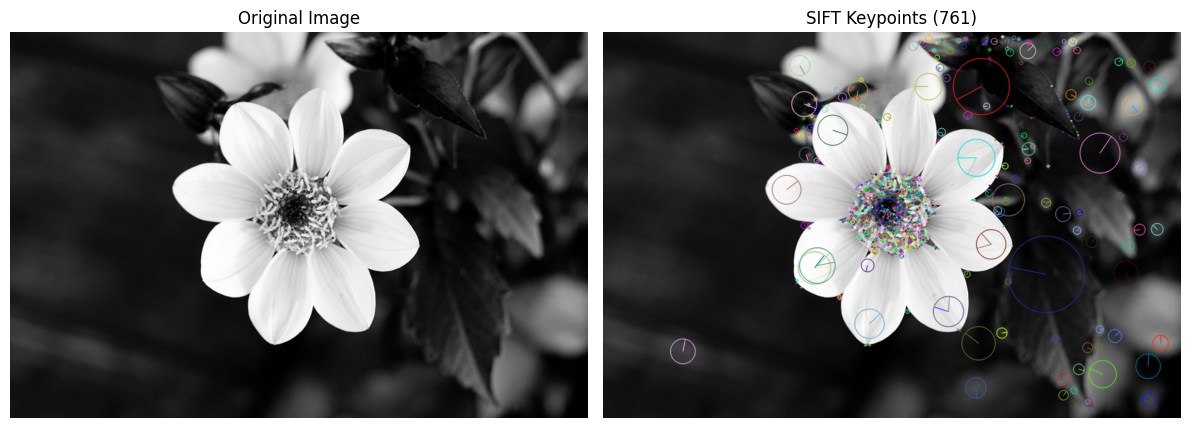

In [3]:
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints, descriptors = sift.detectAndCompute(img, None)

output = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

print("Number of Keypoints Detected:", len(keypoints))

if descriptors is not None:
    print("Descriptor Shape:", descriptors.shape)
    print("\nFirst Descriptor (128-dimensional):")
    print(descriptors[0])

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Keypoints ({len(keypoints)})")
plt.axis("off")

plt.tight_layout()
plt.show()

## Principal Component Analysis (PCA)

In [4]:
from sklearn.decomposition import PCA

Original Image Shape : (635, 950)
Reduced Data Shape   : (635, 40)
Reconstructed Shape  : (635, 950)

Variance Ratio:
[0.44328627 0.16394354 0.08945303 0.06427007 0.03545728 0.0284985
 0.02038747 0.01855839 0.01677876 0.01426385 0.01105841 0.0086522
 0.00731663 0.00641104 0.00555292 0.00504075 0.00421945 0.00392165
 0.00326172 0.00297724 0.00266484 0.00245072 0.00234165 0.00217724
 0.00202483 0.00187007 0.00178071 0.00172701 0.00160196 0.0014019
 0.00129274 0.0012184  0.00103674 0.00100696 0.0009946  0.00090636
 0.00088042 0.00079942 0.00075309 0.00073044]

Total Variance Preserved:
98.29692 %


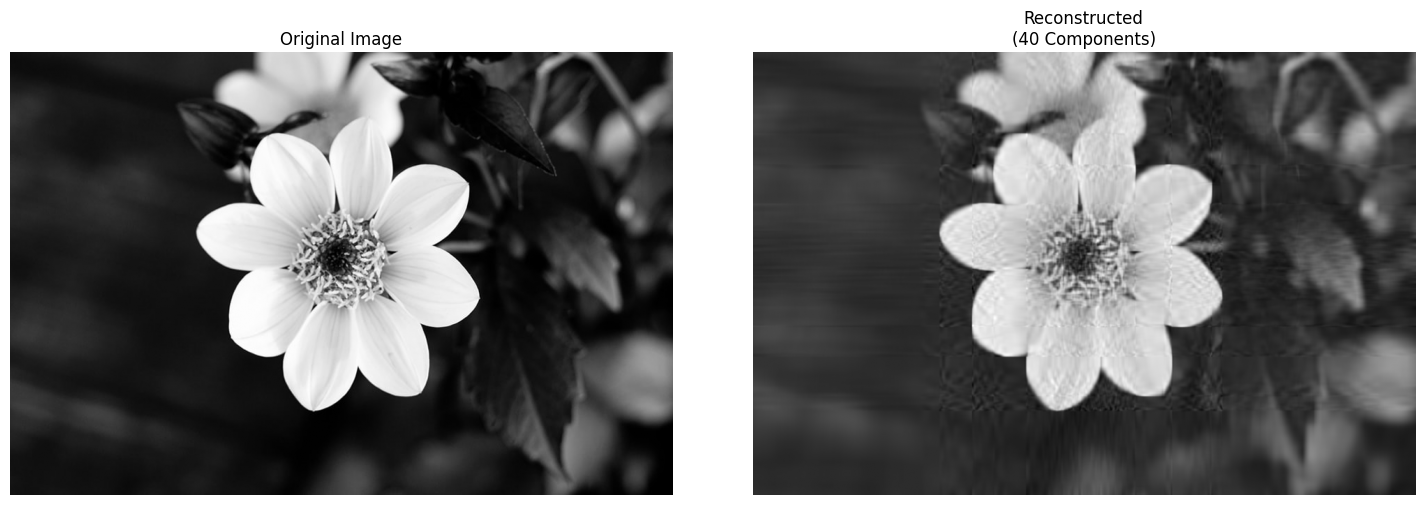

In [7]:
img = img.astype(np.float32)

num_components = 40 

pca = PCA(n_components=num_components)

transformed = pca.fit_transform(img)

reconstructed = pca.inverse_transform(transformed)

error = np.abs(img - reconstructed)

print("Original Image Shape :", img.shape)
print("Reduced Data Shape   :", transformed.shape)
print("Reconstructed Shape  :", reconstructed.shape)

print("\nVariance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Preserved:")
print(np.sum(pca.explained_variance_ratio_) * 100, "%")

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f"Reconstructed\n({num_components} Components)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Classification by Prototype Matching

## Correlation for Prototype Matching

In [19]:
import os

def load_image(path, size=(128, 128)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    if img is None:
        raise ValueError(f"Cannot load {path}")
    img = cv2.resize(img, size)
    return img

Correlation Scores

Circle    : 0.6366
Square    : 0.7417
Triangle  : 0.4751

Predicted Class: Square


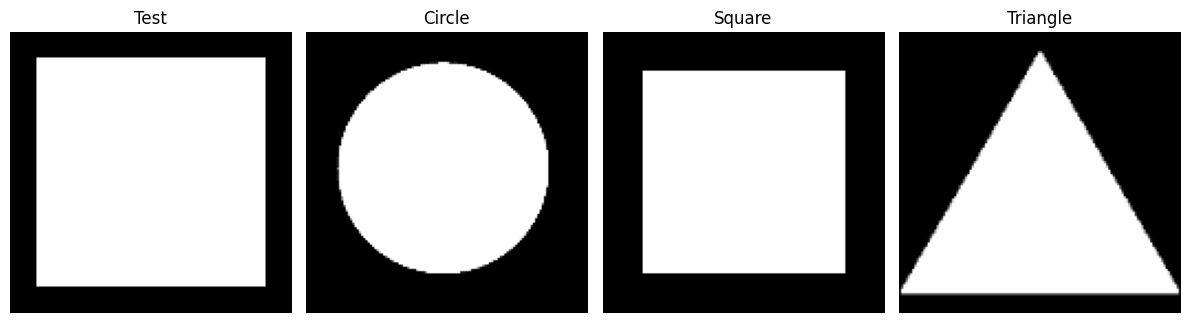

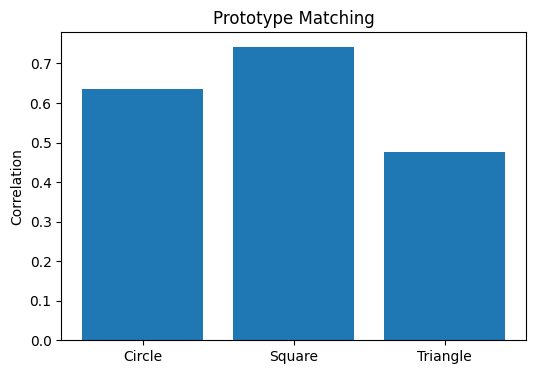

In [21]:
def correlation(img1, img2):
    x = img1.flatten().astype(np.float64)
    y = img2.flatten().astype(np.float64)
    corr = np.corrcoef(x, y)[0, 1] # Pearson Correlation Coefficient
    return corr
    
prototype_folder = "shapes"

prototypes = {
    "Circle": "circle.png",
    "Square": "square.png",
    "Triangle": "triangle.png"
}
prototype_images = {}

for label, filename in prototypes.items():
    path = os.path.join(prototype_folder, filename)
    prototype_images[label] = load_image(path)

test = load_image(os.path.join(prototype_folder, "test.png")) 

scores = {}

print("Correlation Scores\n")

for label, image in prototype_images.items(): # Compare with every prototype

    score = correlation(test, image)

    scores[label] = score

    print(f"{label:10s}: {score:.4f}")
    
prediction = max(scores, key=scores.get) # Best Match
print("\nPredicted Class:", prediction)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(test, cmap='gray')
plt.title("Test")
plt.axis("off")

i = 2
for label, image in prototype_images.items():
    plt.subplot(1,4,i)
    plt.imshow(image, cmap='gray')
    plt.title(label)
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(scores.keys(), scores.values())
plt.ylabel("Correlation")
plt.title("Prototype Matching")
plt.show()

## Matching Structural Prototype - Shape Number


Similarity Scores
Circle    : 0.489
Square    : 0.981
Triangle  : 0.463

Predicted Shape: Square


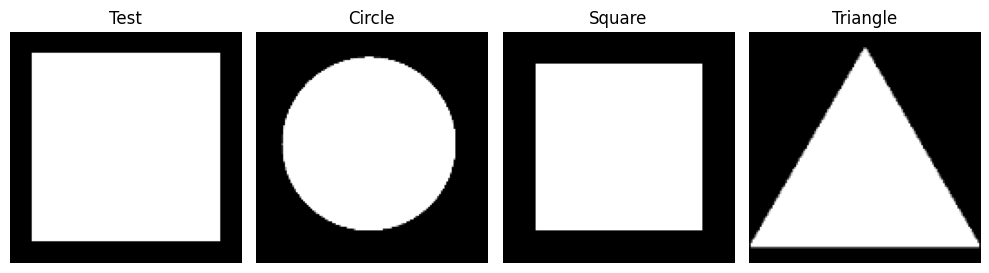

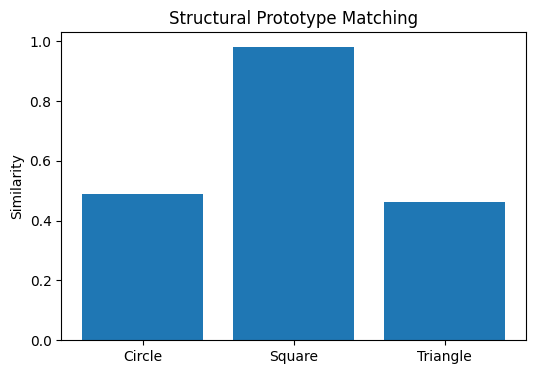

In [22]:
direction_map = {
    (1, 0): 0,
    (1, -1): 1,
    (0, -1): 2,
    (-1, -1): 3,
    (-1, 0): 4,
    (-1, 1): 5,
    (0, 1): 6,
    (1, 1): 7
}
def chain_code(img):
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    binary = 255-binary
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        return []
    contour = max(contours, key=cv2.contourArea)
    code = []
    for i in range(len(contour)-1):
        x1, y1 = contour[i][0]
        x2, y2 = contour[i+1][0]
        dx = np.sign(x2-x1)
        dy = np.sign(y2-y1)
        if (dx, dy) in direction_map:
            code.append(direction_map[(dx, dy)])
    return code
    
def shape_number(chain):
    if len(chain) == 0:
        return []
    diff = []
    for i in range(len(chain)):
        d = (chain[(i+1) % len(chain)] - chain[i]) % 8
        diff.append(d)
    n = len(diff)
    rotations = []
    for i in range(n):
        rotations.append(diff[i:] + diff[:i])
    return min(rotations)

def similarity(shape1, shape2):
    L = min(len(shape1), len(shape2))
    match = 0
    for i in range(L):
        if shape1[i] == shape2[i]:
            match += 1
    return match / L
    
folder = "shapes"
prototypes = {
    "Circle": "circle.png",
    "Square": "square.png",
    "Triangle": "triangle.png"
}
prototype_shapes = {}

for label, file in prototypes.items():
    img = load_image(os.path.join(folder, file))
    cc = chain_code(img)
    sn = shape_number(cc)
    prototype_shapes[label] = sn

test = load_image(os.path.join(folder, "test.png"))
test_shape = shape_number(chain_code(test))
scores = {}

print("\nSimilarity Scores")
for label, proto in prototype_shapes.items():
    score = similarity(test_shape, proto)
    scores[label] = score
    print(f"{label:10s}: {score:.3f}")

prediction = max(scores, key=scores.get)
print("\nPredicted Shape:", prediction)

plt.figure(figsize=(10,4))
plt.subplot(1,4,1)
plt.imshow(test, cmap='gray')
plt.title("Test")
plt.axis("off")

i = 2
for label, image in prototype_images.items():
    plt.subplot(1,4,i)
    plt.imshow(image, cmap='gray')
    plt.title(label)
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(scores.keys(), scores.values())
plt.ylabel("Similarity")
plt.title("Structural Prototype Matching")
plt.show()

## SIFT Keypoint Matching


Matching Scores
Circle    : 0 good matches
Square    : 4 good matches
Triangle  : 0 good matches

Predicted Class: Square


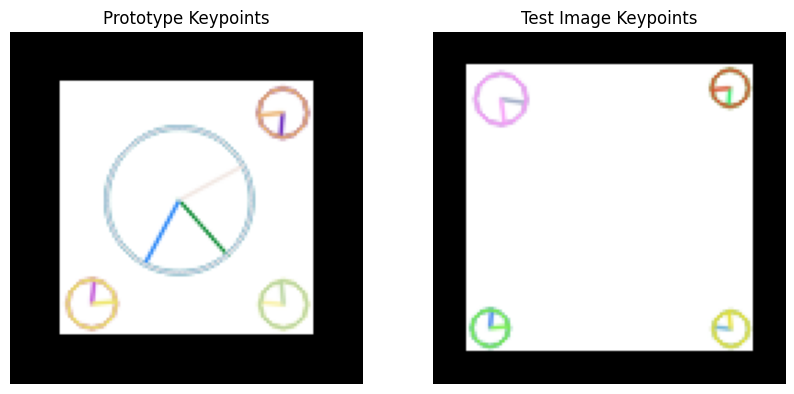

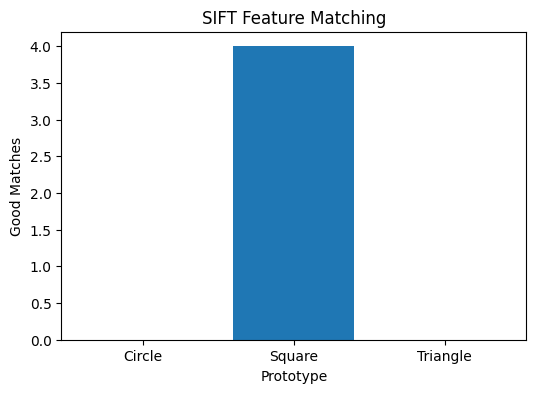

In [20]:
sift = cv2.SIFT_create()
bf = cv2.BFMatcher(cv2.NORM_L2)

folder = "shapes"
prototypes = {
    "Circle": "circle.png",
    "Square": "square.png",
    "Triangle": "triangle.png"
}
test = load_image(os.path.join(folder, "test.png"))
kp_test, des_test = sift.detectAndCompute(test, None)

scores = {}
best_matches = {}
print("\nMatching Scores")

for label, file in prototypes.items():
    prototype = load_image(os.path.join(folder, file))
    kp_proto, des_proto = sift.detectAndCompute(prototype, None)
    if des_proto is None or des_test is None:
        scores[label] = 0
        continue
    matches = bf.knnMatch(des_proto, des_test, k=2) #kNN for matching 
    good = []

    for m, n in matches: # Lowe's Ratio Test
        if m.distance < 0.75 * n.distance:  
            good.append(m)
            
    scores[label] = len(good)
    best_matches[label] = (prototype, kp_proto, good)
    print(f"{label:10s}: {len(good)} good matches")

prediction = max(scores, key=scores.get)
print("\nPredicted Class:", prediction)
prototype, kp_proto, good = best_matches[prediction]

matched = cv2.drawMatches(prototype, kp_proto, test, kp_test, good, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

proto_keypoints = cv2.drawKeypoints(prototype, kp_proto, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
test_keypoints = cv2.drawKeypoints(test, kp_test, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(proto_keypoints)
plt.title("Prototype Keypoints")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(test_keypoints)
plt.title("Test Image Keypoints")
plt.axis("off")

plt.show()

plt.figure(figsize=(6,4))
plt.bar(scores.keys(), scores.values())
plt.xlabel("Prototype")
plt.ylabel("Good Matches")
plt.title("SIFT Feature Matching")
plt.show()

## Template Matching 

Maximum Correlation : 1.0
Top Left : (293, 298)
Template Size : 115 x 29


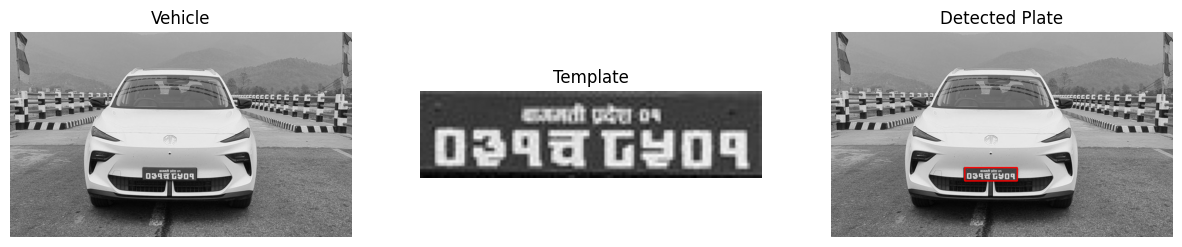

In [7]:
vehicle = cv2.imread("vehicle.jpg")
template = cv2.imread("plate_template.jpg", cv2.IMREAD_GRAYSCALE)
vehicle_gray = cv2.cvtColor(vehicle, cv2.COLOR_BGR2GRAY)

h, w = template.shape

# Template matching correlates to different windows in image
result = cv2.matchTemplate(vehicle_gray, template,cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

output = vehicle_gray.copy()

print("Maximum Correlation :", round(max_val,3))
print("Top Left :", top_left)
print("Template Size :", w, "x", h)

output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
cv2.rectangle(output, top_left, bottom_right, (255, 0, 0), 2)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(vehicle_gray, cmap = "gray")
plt.title("Vehicle")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(template, cmap="gray")
plt.title("Template")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(output)
plt.title("Detected Plate")
plt.axis("off")

plt.show()

# Classification with Supervised Learning Classifiers

## k-Nearest Neighbors(kNN)

In [20]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [11]:
dataset = load_digits()

images = dataset.images # 8×8 images of handwritten digits 0-9
X = dataset.data # Flattened feature vectors (64 features)
y = dataset.target # Labels (0–9)

print("Number of Images :", len(images))
print("Image Shape :", images[0].shape)
print("Feature Vector Shape :", X.shape)

Number of Images : 1797
Image Shape : (8, 8)
Feature Vector Shape : (1797, 64)


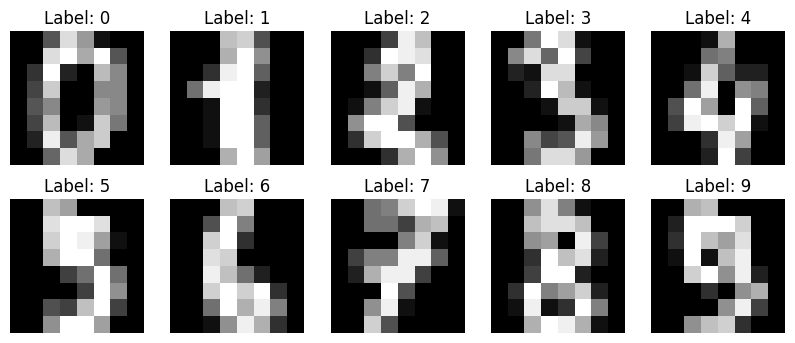

In [12]:
#display sample images
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title("Label: " + str(y[i]))
    plt.axis('off')
plt.show()

In [23]:
# Uses pixel values as feature vector
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 1437
Testing Samples : 360


In [14]:
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [15]:
y_pred = knn.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", round(accuracy*100,2), "%")

Accuracy = 98.33 %


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.97      0.98        30
           9       0.97      0.93      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



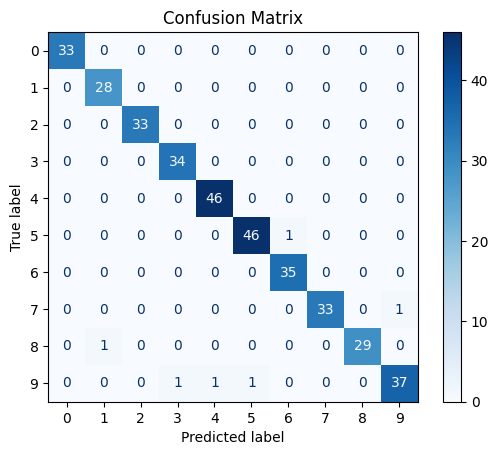

In [22]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.target_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

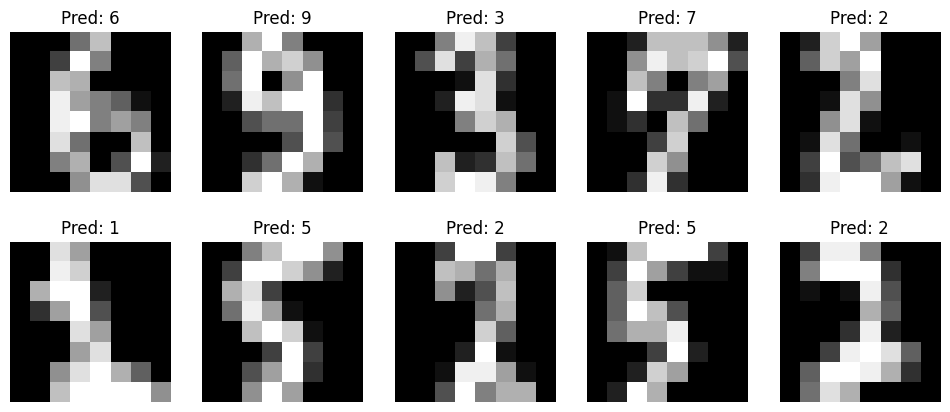

In [19]:
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap='gray')
    plt.title("Pred: " + str(y_pred[i]))
    plt.axis('off')
plt.show()

## Support Vector Machine (SVM)

In [24]:
from sklearn.svm import SVC

In [25]:
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [26]:
y_pred = svm.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy = {:.2f}%".format(accuracy*100))

Accuracy = 98.61%


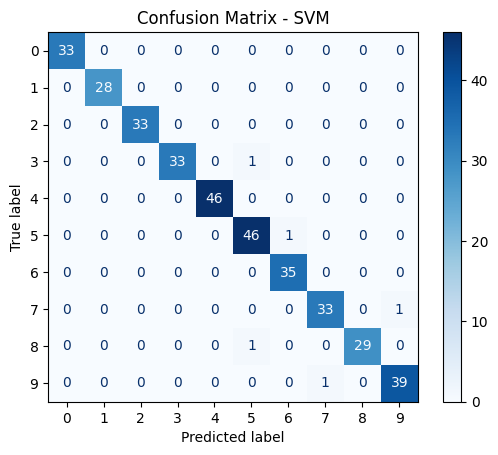

In [29]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.target_names)
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - SVM")
plt.show()

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       1.00      1.00      1.00        46
           5       0.96      0.98      0.97        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.97      0.97      0.97        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



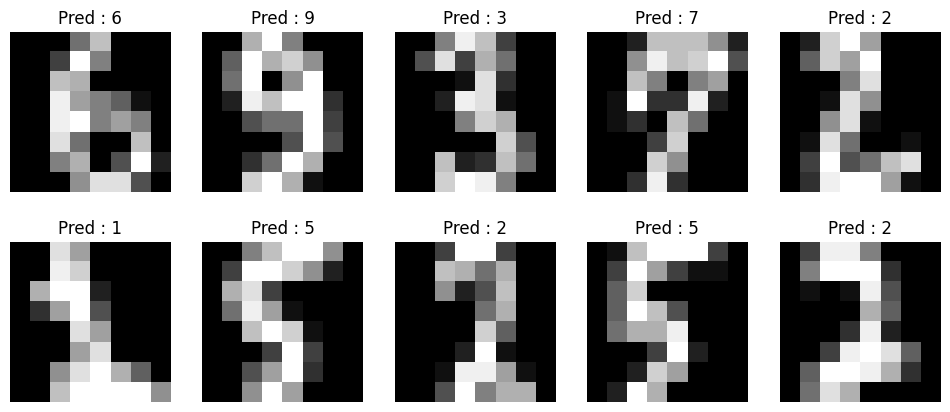

In [31]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap='gray')
    plt.title("Pred : " + str(y_pred[i]))
    plt.axis('off')

plt.show()

## Naïve Bayes Classifier

In [32]:
from sklearn.naive_bayes import GaussianNB

In [33]:
nb = GaussianNB()
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](10,)","[145.,154.,144.,...,145.,144.,140.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](10,)","[0.1 ,0.11,0.1 ,...,0.1 ,0.1 ,0.1 ]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,4.261e-08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,64
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](10, 64)","[[ 0. , 0.01, 4.16,..., 5.35, 0.22, 0. ], [ 0. , 0.01, 2.44,..., 8.41, 2.92, 1.39], [ 0. , 0.98, 9.84,...,12.01, 8.31, 2.01], ..., [ 0. , 0.12, 4.98,..., 0.01, 0. , 0. ], [ 0. , 0.14, 5.1 ,..., 6.73, 1.1 , 0.01], [ 0. , 0.11, 5.61,..., 8.94, 2.09, 0.05]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](10, 64)","[[ 0. , 0.03, 8.02,...,13.54, 0.56, 0. ], [ 0. , 0.01,11.78,...,39.05,27.44,15.06], [ 0. , 1.95,21.33,...,16.95,33.98,13.74], ..., [ 0. , 0.3 ,14.01,..., 0.01, 0. , 0. ], [ 0. , 0.24,18.27,...,27.32, 8.28, 0.03], [ 0. , 0.13,15.9 ,...,28.67,13.05, 0.06]]"


In [34]:
y_pred = nb.predict(X_test)

In [35]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy = {:.2f}%".format(accuracy*100))

Accuracy = 84.72%


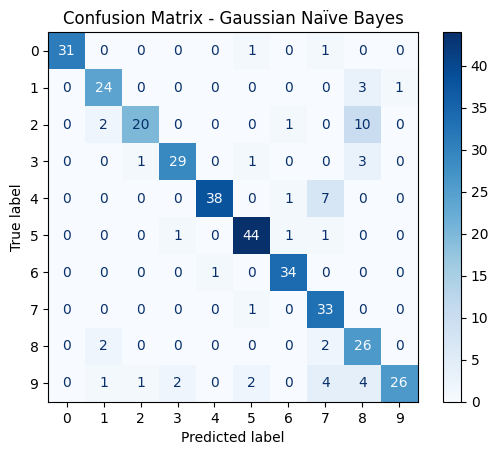

In [36]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.target_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Gaussian Naïve Bayes")
plt.show()

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        33
           1       0.83      0.86      0.84        28
           2       0.91      0.61      0.73        33
           3       0.91      0.85      0.88        34
           4       0.97      0.83      0.89        46
           5       0.90      0.94      0.92        47
           6       0.92      0.97      0.94        35
           7       0.69      0.97      0.80        34
           8       0.57      0.87      0.68        30
           9       0.96      0.65      0.78        40

    accuracy                           0.85       360
   macro avg       0.86      0.85      0.84       360
weighted avg       0.88      0.85      0.85       360



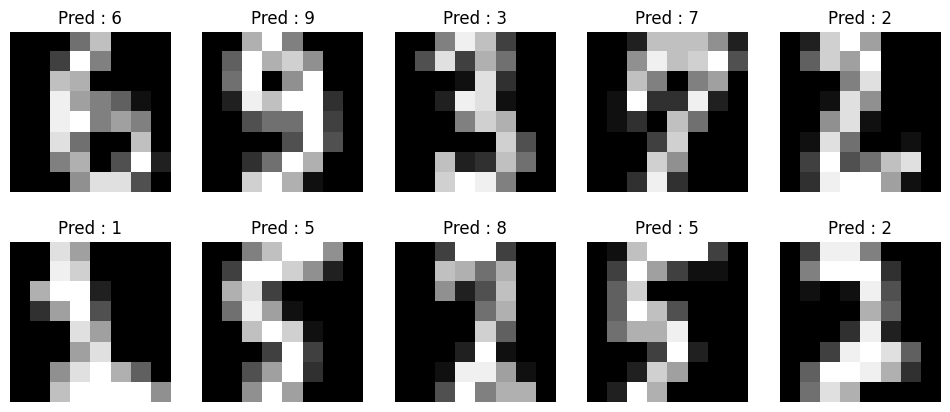

In [38]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap="gray")
    plt.title("Pred : " + str(y_pred[i]))
    plt.axis("off")

plt.show()